# **Laboratorio 10 - Visión por Computadora**

- Paula Barillas - 22764
- Gerardo Pineda - 22880
- Mónica Salvatierra - 22249

Link del repositorio: https://github.com/paulabaal12/LAB10-VCP

## **Task 1**

In [1]:
!pip install diffusers transformers accelerate torch torchvision Pillow

### Librerias

In [4]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline, DDIMScheduler
import warnings
warnings.filterwarnings("ignore")

### Scheduler y semilla

In [5]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None,
)
pipe = pipe.to("cuda")
pipe.enable_attention_slicing()

print("Modelo cargado en:", next(pipe.unet.parameters()).device)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

Modelo cargado en: cuda:0


In [ ]:
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

SEED = 42
NUM_STEPS = 20
PROMPT = (
    "A highly detailed cinematic and futuristic fruit glowing in a cyberpunk laboratory, "
    "intricate geometric patterns on the surface, complex fractal textures, "
    "neon lights reflecting on metallic and glass materials, volumetric lighting, "
    "high contrast shadows, holographic elements, ultra sharp focus, 4k resolution, "
    "depth of field, dramatic composition, realistic reflections, subsurface scattering, "
    "sci-fi atmosphere"
)
NEGATIVE_PROMPT = "blurry, low quality, flat, plain, simple, dark, noisy"

CAPTURE_STEPS = {4, 10, 16, 20}

print(f"Seed: {SEED} | Steps: {NUM_STEPS} | Capturando en: {CAPTURE_STEPS}")

Seed: 42 | Steps: 20 | Capturando en: {16, 10, 4, 20}


In [7]:
generator = torch.manual_seed(SEED)

text_inputs = pipe.tokenizer(
    PROMPT,
    padding="max_length",
    max_length=pipe.tokenizer.model_max_length,
    truncation=True,
    return_tensors="pt",
)
text_embeddings = pipe.text_encoder(text_inputs.input_ids.to("cuda"))[0]

In [8]:
uncond_inputs = pipe.tokenizer(
    NEGATIVE_PROMPT,
    padding="max_length",
    max_length=pipe.tokenizer.model_max_length,
    truncation=True,
    return_tensors="pt",
)
uncond_embeddings = pipe.text_encoder(uncond_inputs.input_ids.to("cuda"))[0]

In [9]:
text_embeddings_cfg = torch.cat([uncond_embeddings, text_embeddings])

latents = torch.randn(
    (1, pipe.unet.config.in_channels, 64, 64),
    generator=generator,
    dtype=torch.float16,
).to("cuda")

pipe.scheduler.set_timesteps(NUM_STEPS)
latents = latents * pipe.scheduler.init_noise_sigma

In [10]:
captured_latents = {}

for i, t in enumerate(pipe.scheduler.timesteps):
    step_number = i + 1   # steps van de 1 a 20

    # se duplica el latente para CFG (uncond + cond)
    latent_input = torch.cat([latents] * 2)
    latent_input = pipe.scheduler.scale_model_input(latent_input, t)

    # predicción del ruido con U-Net
    with torch.no_grad():
        noise_pred = pipe.unet(latent_input, t, encoder_hidden_states=text_embeddings_cfg).sample

    # se separa la predicción uncondicionada y condicionada
    noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)

    # se aplica Classifier-Free Guidance
    guidance_scale = 7.5
    noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

    # actualiza el latente
    latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample
    
    if step_number in CAPTURE_STEPS:
        captured_latents[step_number] = latents.clone()
        print(f"Latente capturado en paso {step_number}")

print("\nCaptura completa. Pasos guardados:", sorted(captured_latents.keys()))

Latente capturado en paso 4
Latente capturado en paso 10
Latente capturado en paso 16
Latente capturado en paso 20

Captura completa. Pasos guardados: [4, 10, 16, 20]


In [11]:
def decode_latent(pipe, latent):
    scaling_factor = pipe.vae.config.scaling_factor
    latent_decoded = latent / scaling_factor

    with torch.no_grad():
        image_tensor = pipe.vae.decode(latent_decoded).sample   # shape: (1, 3, H, W)

    image_tensor = (image_tensor / 2 + 0.5).clamp(0, 1)
    image_np = image_tensor.squeeze(0).permute(1, 2, 0).cpu().float().numpy()
    image_pil = Image.fromarray((image_np * 255).astype(np.uint8))
    return image_pil


decoded_images = {}
for step, latent in sorted(captured_latents.items()):
    decoded_images[step] = decode_latent(pipe, latent)
    print(f"Imagen decodificada para paso {step}")

Imagen decodificada para paso 4
Imagen decodificada para paso 10
Imagen decodificada para paso 16
Imagen decodificada para paso 20


In [12]:
for step, img in decoded_images.items():
    filename = f"latent_step_{step:02d}.png"
    img.save(filename)
    print(f"Guardada: {filename}")

Guardada: latent_step_04.png
Guardada: latent_step_10.png
Guardada: latent_step_16.png
Guardada: latent_step_20.png


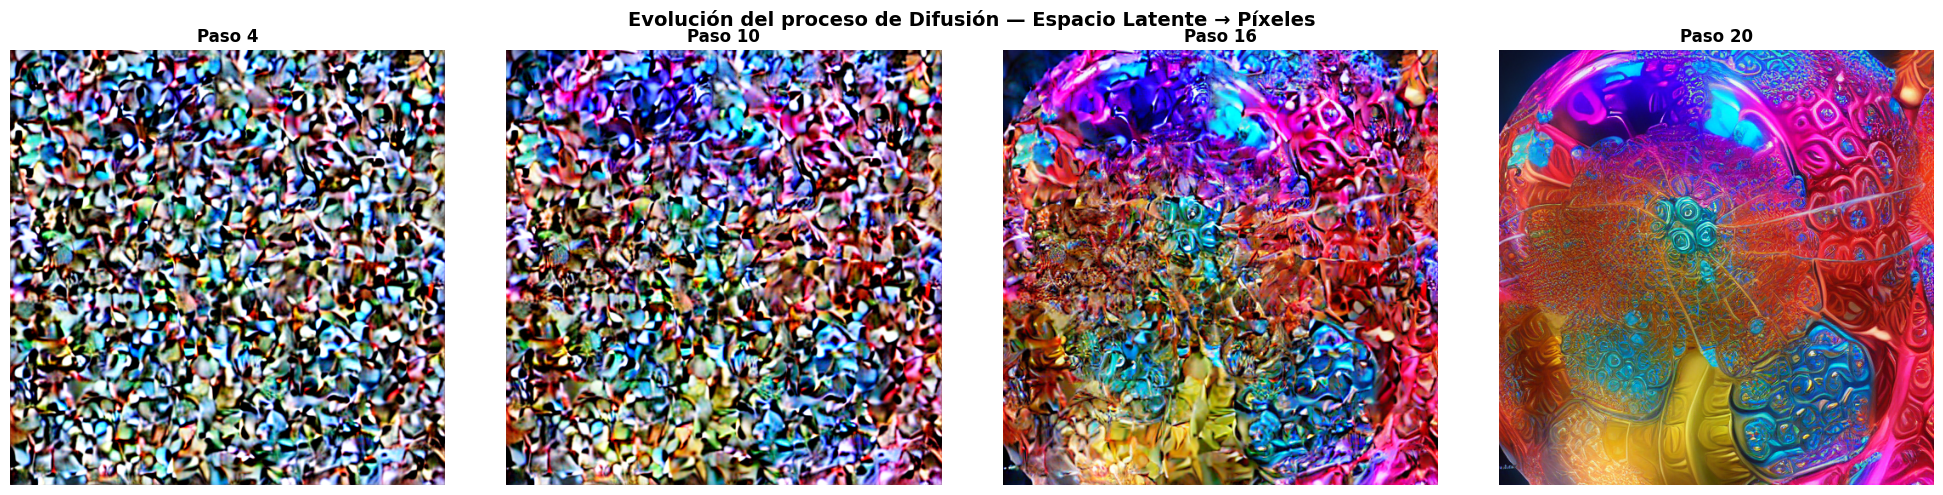

In [14]:
steps_to_show = sorted(decoded_images.keys())   # [4, 10, 16, 20]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    "Evolución del proceso de Difusión — Espacio Latente → Píxeles",
    fontsize=14, fontweight="bold"
)

for ax, step in zip(axes, steps_to_show):
    ax.imshow(decoded_images[step])
    ax.set_title(f"Paso {step}", fontsize=12, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig("evolucion_difusion.png", dpi=150, bbox_inches="tight")
plt.show()